"""
High Energy Polarization Signatures from AGN Jets

Title:
Reproduction of Figure 2 from Polarization of Prompt Gamma-Ray Burst Emission by M.Lyutikov, et. al.(2003)

Author:
Dhanad Jha

Supervisor:
Dr. Bhargav Vaidya, IIT Indore

GitHub:
https://github.com/Dhanad1905/High-Energy-Polarization-Signatures-From-AGN-Jets/tree/main

"""

In [79]:
import numpy as np
import pandas as pd
from scipy.integrate import dblquad

theta_obs=0.1
Gamma=10
beta=np.sqrt(1 - 1/Gamma**2)
z0=1.0
OmegaR0=100
p_optical=4.6
p_xray=2.3

def magnetic_field(q, z, R, Bp=1.0):
    R0_z=(z/z0)**q
    Omega_z=OmegaR0*(z/z0)**q
    r_norm=R/R0_z
    Theta=(q*(3**(0.25*q))*r_norm)/(OmegaR0)**((1-q)/q)

    ER=Omega_z*R*Bp*np.cos(Theta)
    Ephi=0
    Ez=-Omega_z*R*Bp*np.sin(Theta) 
    #E=np.array([ER,Ephi,Ez])
    
    BR=Bp*np.sin(Theta)
    Bz=Bp*np.cos(Theta)
    Bphi_sq=(ER**2+Ez**2)+((Bp**2)*((3**(-1+1/(2*q)))*q*(1-q)*(Omega_z*R)**4/(OmegaR0)**(2/q)))
    Bphi=np.sqrt(Bphi_sq)

    return BR,Bphi,Bz

#Stokes integrands using |B × n| formulation (Lyutikov et al. 2005; Appendix D)
def integrands(phi, R, z, q, p, Ke_model, component='I'):
    BR,Bphi,Bz = magnetic_field(q, z, R)

    Bx=BR*np.cos(phi)-Bphi*np.sin(phi)
    By=BR*np.sin(phi)+Bphi*np.cos(phi)
    Bz=Bz
    B=np.array([Bx,By,Bz])
    n=np.array([np.sin(theta_obs),0,np.cos(theta_obs)])

    B_cross_n = np.cross(B, n)
    B_perp_sq = np.dot(B_cross_n, B_cross_n) + 1e-20
    cos2chi = (B_cross_n[0]**2 - B_cross_n[1]**2) / B_perp_sq
    sin2chi = -2 * B_cross_n[0] * B_cross_n[1] / B_perp_sq

    if Ke_model=='constant':
        Ke=1.0
    else:
        Ke=(Bx**2 + By**2 + Bz**2)
    delta = 1 / (Gamma * (1 - beta * np.cos(theta_obs)))
    factor = Ke * delta**((3 + p)/2) * B_perp_sq**((p + 1)/4)

    if component == 'I':
        return R * factor
    elif component == 'Q':
        return R * factor * cos2chi
    elif component == 'U':
        return R * factor * sin2chi
    else:
        raise ValueError("Invalid Stokes component")

def compute_stokes(q, p, Ke_model, z_start, z_end, Nz=20):
    Q=U=I=0.0
    z_vals=np.linspace(z_start, z_end, Nz)
    dz=(z_end-z_start) / Nz

    for z in z_vals:
        R0_z=(z/z0)**q

        def bounds_phi(): return 0, 2*np.pi
        def bounds_R(phi): return 0, R0_z

        Iz,_=dblquad(lambda phi, R: integrands(phi, R, z, q, p, Ke_model, 'I'),
                        *bounds_phi(), lambda phi: 0, lambda phi: R0_z)
        Qz,_=dblquad(lambda phi, R: integrands(phi, R, z, q, p, Ke_model, 'Q'),
                        *bounds_phi(), lambda phi: 0, lambda phi: R0_z)
        Uz,_=dblquad(lambda phi, R: integrands(phi, R, z, q, p, Ke_model, 'U'),
                        *bounds_phi(), lambda phi: 0, lambda phi: R0_z)

        I+=Iz * dz
        Q+=Qz * dz
        U+=Uz * dz

    Pi=np.sqrt(Q**2 + U**2) / I if I > 0 else 0
    return round(Pi, 4)

q_values=[0.6, 0.7, 0.8]
results=[]

for Ke_model in ['constant', 'squared']:
    for q in q_values:
        Pi_O = compute_stokes(q, p_optical, Ke_model, z0, z0 + 1e-3)
        Pi_X_2 = compute_stokes(q, p_xray, Ke_model, z0, 3*z0)
        Pi_X_4 = compute_stokes(q, p_xray, Ke_model, z0, 5*z0)
        results.append({
            'q': q,
            'Ke_model': 'Ke = const' if Ke_model == 'constant' else 'Ke ∝ B^2',
            'Π_O (Δz→0)': Pi_O,
            'Π_X (Δz=2z₀)': Pi_X_2,
            'Π_X (Δz=4z₀)': Pi_X_4
        })

df_results = pd.DataFrame(results)
print(df_results)


     q    Ke_model  Π_O (Δz→0)  Π_X (Δz=2z₀)  Π_X (Δz=4z₀)
0  0.6  Ke = const      0.8353        0.5867        0.3420
1  0.7  Ke = const      0.8353        0.5070        0.1909
2  0.8  Ke = const      0.8352        0.4103        0.0810
3  0.6    Ke ∝ B^2      0.8353        0.5639        0.3018
4  0.7    Ke ∝ B^2      0.8353        0.4739        0.1313
5  0.8    Ke ∝ B^2      0.8352        0.3654        0.0559


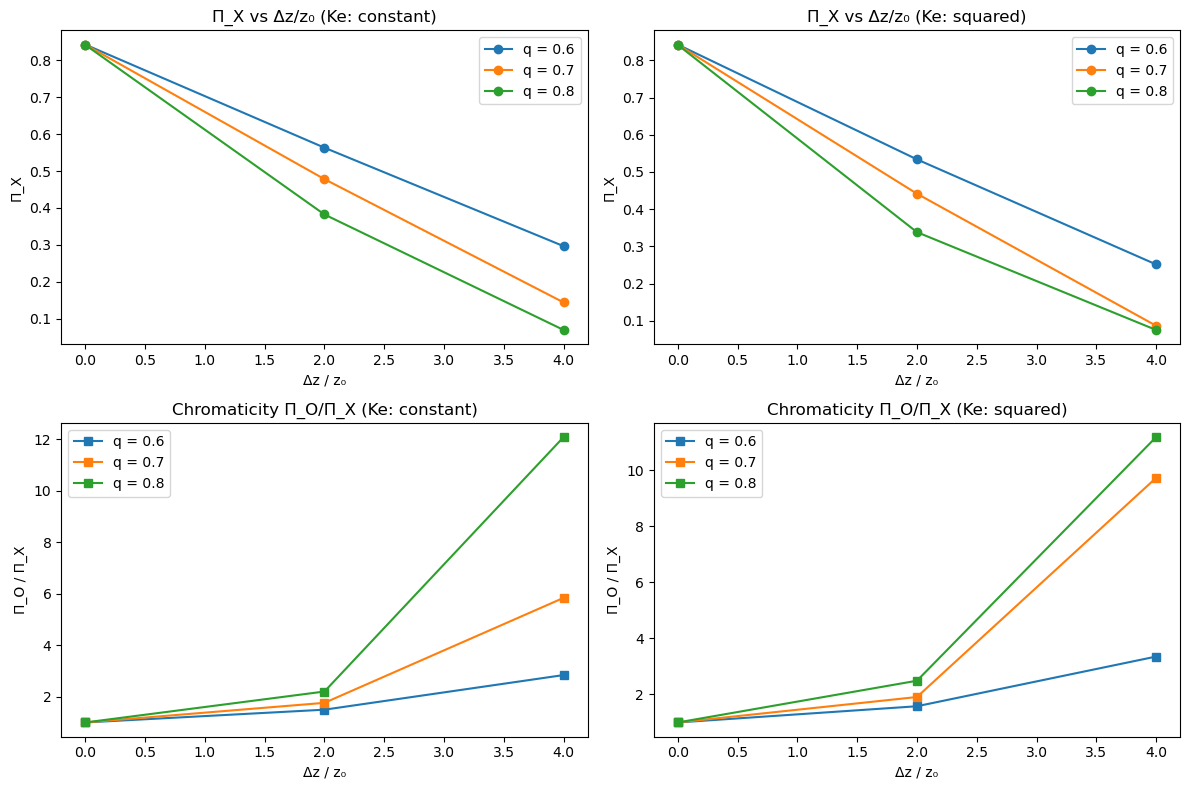

In [34]:
q_values = [0.6, 0.7, 0.8]
dz_values = [0, 2, 4]
Ke_models = ['constant', 'squared']

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for col, Ke_model in enumerate(Ke_models):
    for q in q_values:
        Pi_O = compute_stokes(q, p_optical, Ke_model, z0, z0)
        Pi_X_vals = []
        chrom_vals = []
        for dz in dz_values:
            Pi_X = compute_stokes(q, p_xray, Ke_model, z0, z0 + dz)
            Pi_X_vals.append(Pi_X)
            chrom_vals.append(Pi_O / Pi_X if Pi_X != 0 else 0)
        label = f"q = {q}"
        axs[0, col].plot(dz_values, Pi_X_vals, marker='o', label=label)
        axs[0, col].set_title(f"Π_X vs Δz/z₀ (Ke: {Ke_model})")
        axs[0, col].set_xlabel("Δz / z₀")
        axs[0, col].set_ylabel("Π_X")
        axs[0, col].legend()

        axs[1, col].plot(dz_values, chrom_vals, marker='s', label=label)
        axs[1, col].set_title(f"Chromaticity Π_O/Π_X (Ke: {Ke_model})")
        axs[1, col].set_xlabel("Δz / z₀")
        axs[1, col].set_ylabel("Π_O / Π_X")
        axs[1, col].legend()

plt.tight_layout()
plt.show()
